In [ ]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter

In [2]:
function select(values,val,v1)
    index=findall(x->x==values,val)
    vec = v1[:,index]
    u = vec[1:N_cheb-1,1]
    v = vec[N_cheb:2*(N_cheb-1),1]
    w = vec[2*(N_cheb)-1:3*(N_cheb-1),1]
    u = [0;u;0]
    v = [0;v;0]
    w = [0;w;0]
    return vec,u,v,w
end

select (generic function with 1 method)

In [ ]:
# parameters

N_cheb = 99
Re = 358
R = Re
Mr = 0.04
Ma = Mr/R
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T ;
println("Baseflow done")
# caculate_module

netual_cur = [empty! empty! empty!]
grad_mat = [-10]
cacu_point = [empty! empty! empty!]
start_point =  [empty! empty! empty!]
point = 0
be = 0
@showprogress for be = 0.035:0.0001:0.1

    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = 0.05, neigs = 1,maxit = 500);
    point = filter(x -> -0.0001 < imag(x) < 0 && real(x)>0.05, eigval)

    if point !=  []

        println("start_beta = ",be)
        println("eigenvalue = ",point)
        cacu_point = [Re be point]
        netual_cur = [netual_cur; cacu_point]
        start_point = [Re be point]
        break
        
    end

end
println("initial point done")
for be = real(start_point[1,2])+0.001 : 0.001 : 0.06

    point = cacu_point[3]
    point_temp = []

        while point != []

            Ma = Mr/R
            u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
            H,T = T_ca(Mr,f,q,w0,gamma,Tw)
            F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
            lam = - (2/3) * T
            kappa = (1/sigma) * T 
            A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = cacu_point[3] , neigs = 1 ,maxit = 500,tol=1e-10)
            point = filter(x -> - 0.0001 < imag(x) < 0.005 && real(x)>0.05, eigval)
            point_temp = [point_temp;point]
            
        end

        cacu_point = [R be + 10^-5 point_temp[end]]
        netual_cur = [netual_cur; cacu_point]
        grad = (netual_cur[end,1] - netual_cur[end-1,1])/(10^3 * (netual_cur[end,2] - netual_cur[end-1,2]))
        grad_mat = [grad_mat; grad]
        println("grad = ",grad) 

end 

In [111]:
N_cheb = 99
Mr = 0.3
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
c = 0.3 
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [-1 -1 -1]
for R = 280 : 1 : 500
    Ma = Mr/R
    global u0,v0,w0,f, q,D,D2,x = baseflow_var(N_cheb)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num :: Int64 = 3
    for be = 0.02 : 0.001 : 0.15
        A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 1000,tol=1e-10)
        point = filter(x -> - 0.2 < imag(x) < 0 && real(x)>0.05, eigval)
        if point == []

            eig = - 1
            c = 0.3
            
        elseif netural_cur[end,3] == -1 && imag(point[1]) < -0.0005

            eig = -1

        else
            
            eig = point[findmin(x-> abs(imag(x)), point)[2]]
            c = eig
            num = 2

        end
        netural_cur = [netural_cur; [R be eig]]
        netural_cur_real = [netural_cur_real; [R be real(eig)]]
        netural_cur_imag = [netural_cur_imag; [R be imag(eig)]]
    end

end

In [112]:
netural_cur[5581,3]

0.49619742720418397 - 0.00019711906047864422im

In [114]:
writedlm("test_neturalcur_imag.dat",netural_cur_imag)
writedlm("test_neturalcur_real.dat",netural_cur_real)
writedlm("test_neturalcur.dat",netural_cur)

In [67]:
N_cheb = 149
Mr = 0.1
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
c = 0.2
R = 470
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
netural_cur = [-1 -1 -1]
netural_cur_real = [-1 -1 -1]
netural_cur_imag = [-1 -1 -1]
num :: Int64 = 3
@showprogress for be = 0.02 : 0.001 : 0.15
    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    point = filter(x -> - 0.2 < imag(x) < 0 && real(x)>0.05, eigval)
    if point == []

        eig = - 1
        c = 0.2
        
    # elseif netural_cur[end,3] == -1 && imag(point[1]) < -0.0005

    #     eig = -1

    else
        
        eig = point[findmin(x-> abs(imag(x)), point)[2]]
        c = eig
        num = 2

    end
    netural_cur = [netural_cur; [R be eig]]
    netural_cur_real = [netural_cur_real; [R be real(eig)]]
    netural_cur_imag = [netural_cur_imag; [R be imag(eig)]]
end

println("R = ",R)

Progress: 100%|█████████████████████████████████████████| Time: 0:01:43


R = 470


In [16]:
netural_cur[67,3]

0.43147737944113934 - 0.00043998231952226325im

In [69]:

N_cheb = 149
Mr = 0.1
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
R = 470
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
be = 0.129
A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = 0.2, neigs = 3 ,maxit = 500,tol=1e-10)
point = filter(x -> - 0.1 < imag(x) < 0.0005 && real(x)>0.05, eigval)

ComplexF64[]

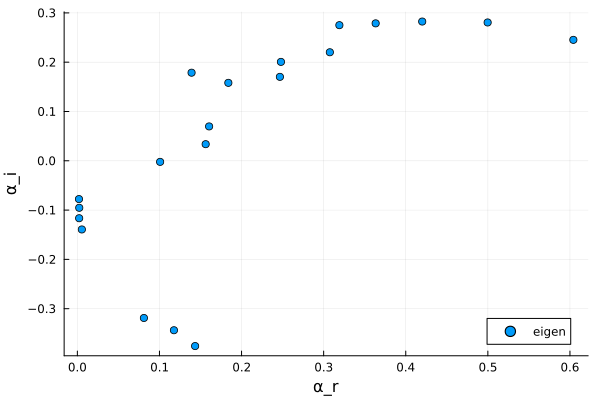

In [65]:
scatter(real(eigval),imag(eigval),xlabel ="α_r",ylabel="α_i",label="eigen")